# Trading Algorithm Research

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
prices = yf.download("NVDA", start="2022-01-01")
prices

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2022-01-03,29.992588,30.580073,29.658020,29.687893,391547000
2022-01-04,29.165127,30.338104,28.228139,30.147918,527154000
2022-01-05,27.486317,29.290592,27.415620,28.825582,498064000
2022-01-06,28.057863,28.316755,26.949610,27.522157,454186000
2022-01-07,27.130835,28.300826,26.941644,28.021024,409939000
...,...,...,...,...,...
2026-10-01,230.860001,232.289993,228.160004,229.979996,98591400
2026-10-02,233.949997,237.880005,233.600006,236.059998,135167800


## Generating BUY/SELL signals
* Simple Moving Average (SMA) over a 20 and 50 day window
* Relative Strength Index (RSI) over a 14 days window

In [3]:
# SMA fast/slow
prices["sma_fast"] = prices["Close"].rolling(20).mean()
prices["sma_slow"] = prices["Close"].rolling(50).mean()

# RSI
delta = prices["Close"].diff()
gain = delta.clip(lower=0) # positive changes, 0 otherwise
loss = -delta.clip(upper=0) # negative changes, flipped positive
avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()
rs = avg_gain / avg_loss
prices["rsi"] = 100 - (100 / (1 + rs))

# Generating BUY/SELL signals based on the data computed above
prices["sma_signal"] = np.where(prices["sma_fast"] > prices["sma_slow"], 1, 0)
prices["signal"] = np.where( # The filtered signal: SMA says buy AND RSI confirms momentum
    (prices["sma_signal"] == 1) & (prices["rsi"] > 50), 1,
    np.where((prices["sma_signal"] == 0) & (prices["rsi"] < 50), 0, np.nan)
)
prices["signal"] = prices["signal"].ffill()
prices["trade"] = prices["signal"].diff()

prices

Price,Close,High,Low,Open,Volume,sma_fast,sma_slow,rsi,sma_signal,signal,trade
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,
Date,,,,,,,,,,,
2022-01-03,29.992588,30.580073,29.658020,29.687893,391547000,NaN,NaN,NaN,0,NaN,NaN
2022-01-04,29.165127,30.338104,28.228139,30.147918,527154000,NaN,NaN,NaN,0,NaN,NaN
2022-01-05,27.486317,29.290592,27.415620,28.825582,498064000,NaN,NaN,NaN,0,NaN,NaN
2022-01-06,28.057863,28.316755,26.949610,27.522157,454186000,NaN,NaN,NaN,0,NaN,NaN
2022-01-07,27.130835,28.300826,26.941644,28.021024,409939000,NaN,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2026-10-01,230.860001,232.289993,228.160004,229.979996,98591400,223.460244,217.610617,66.070087,1,1.0,0.0
2026-10-02,233.949997,237.880005,233.600006,236.059998,135167800,223.748011,218.119084,82.965319,1,1.0,0.0


In [4]:
prices.describe()

Price,Close,High,Low,Open,Volume,sma_fast,sma_slow,rsi,sma_signal,signal,trade
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,
count,1195.000000,1195.000000,1195.000000,1195.000000,1.195000e+03,1176.000000,1146.000000,1181.000000,1195.000000,1181.000000,1180.000000
mean,98.755620,100.368958,97.059200,98.797070,3.634747e+08,98.274082,97.636229,55.039713,0.604184,0.595258,0.000847
std,70.265548,71.256054,69.326986,70.371376,1.936899e+08,69.343133,68.040179,16.356197,0.489230,0.491050,0.139669
min,11.186727,11.692904,10.774210,10.931644,6.552850e+07,12.173125,12.965808,8.187906,0.000000,0.000000,-1.000000
25%,26.848933,27.225360,26.327461,26.748129,1.887124e+08,25.799923,25.931363,42.636964,0.000000,0.000000,0.000000
50%,94.510513,96.100988,92.238998,94.100698,3.548657e+08,99.034890,102.405653,54.493944,1.000000,1.000000,0.000000
75%,170.695213,172.387132,168.476844,170.846035,4.884630e+08,172.674919,163.726942,66.960502,1.000000,1.000000,0.000000
max,239.240005,243.369995,238.929993,242.100006,1.543911e+09,225.578500,220.437505,98.629053,1.000000,1.000000,1.000000


In [5]:
buys = prices[prices["trade"] == 1]
sells = prices[prices["trade"] == -1]

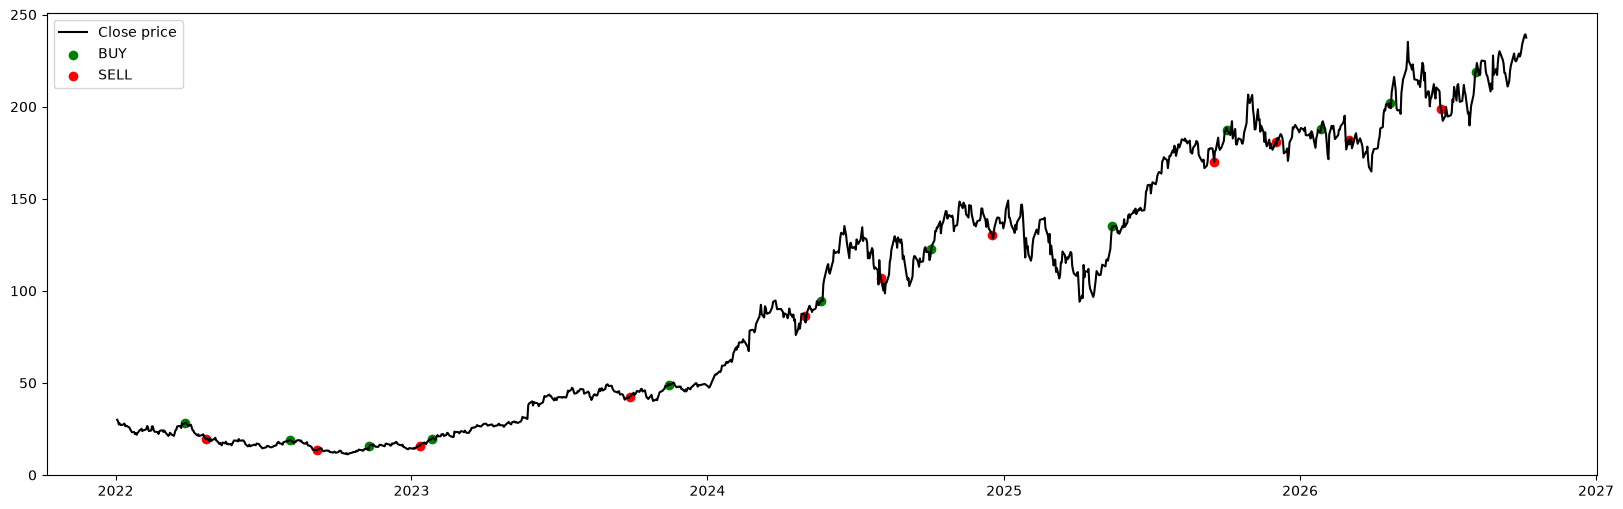

In [6]:
plt.figure(figsize=(20, 6))
plt.plot(prices.index, prices["Close"], label="Close price", color="black")
#plt.plot(prices.index, prices["sma_fast"], label="sma fast", color="orange")
#plt.plot(prices.index, prices["sma_slow"], label="sma slow", color="blue")
plt.scatter(buys.index, buys["Close"], label="BUY", color="green")
plt.scatter(sells.index, sells["Close"], label="SELL", color="red")
plt.legend()
plt.show()

## FinBERT news sentiment overlay
Loads the output of `finbert_sentiment.py` (`score = P(positive) - P(negative)`, from -1 to +1), averages it per day and lays it over the BUY/SELL chart above.

In [13]:
TICKER = "NVDA"
NEWS_CSV = "../news_scored_all.csv"   # produced by finbert_sentiment.py
SMOOTH_DAYS = 5                    # rolling window for the sentiment line

news = pd.read_csv(NEWS_CSV, parse_dates=["date"])
news = news[news["ticker"] == TICKER]

# One number per calendar day: mean FinBERT score + headline count
daily = news.groupby("date").agg(sentiment=("score", "mean"), n_news=("score", "size"))

# Align to trading days (prices index). Days with no news -> NaN (not 0, so gaps stay visible)
close = prices["Close"].iloc[:, 0]
sent = daily["sentiment"].reindex(close.index)
sent_smooth = sent.rolling(SMOOTH_DAYS, min_periods=1).mean()
print(f"{sent.notna().sum()} of {len(sent)} trading days have news")

491 of 1195 trading days have news


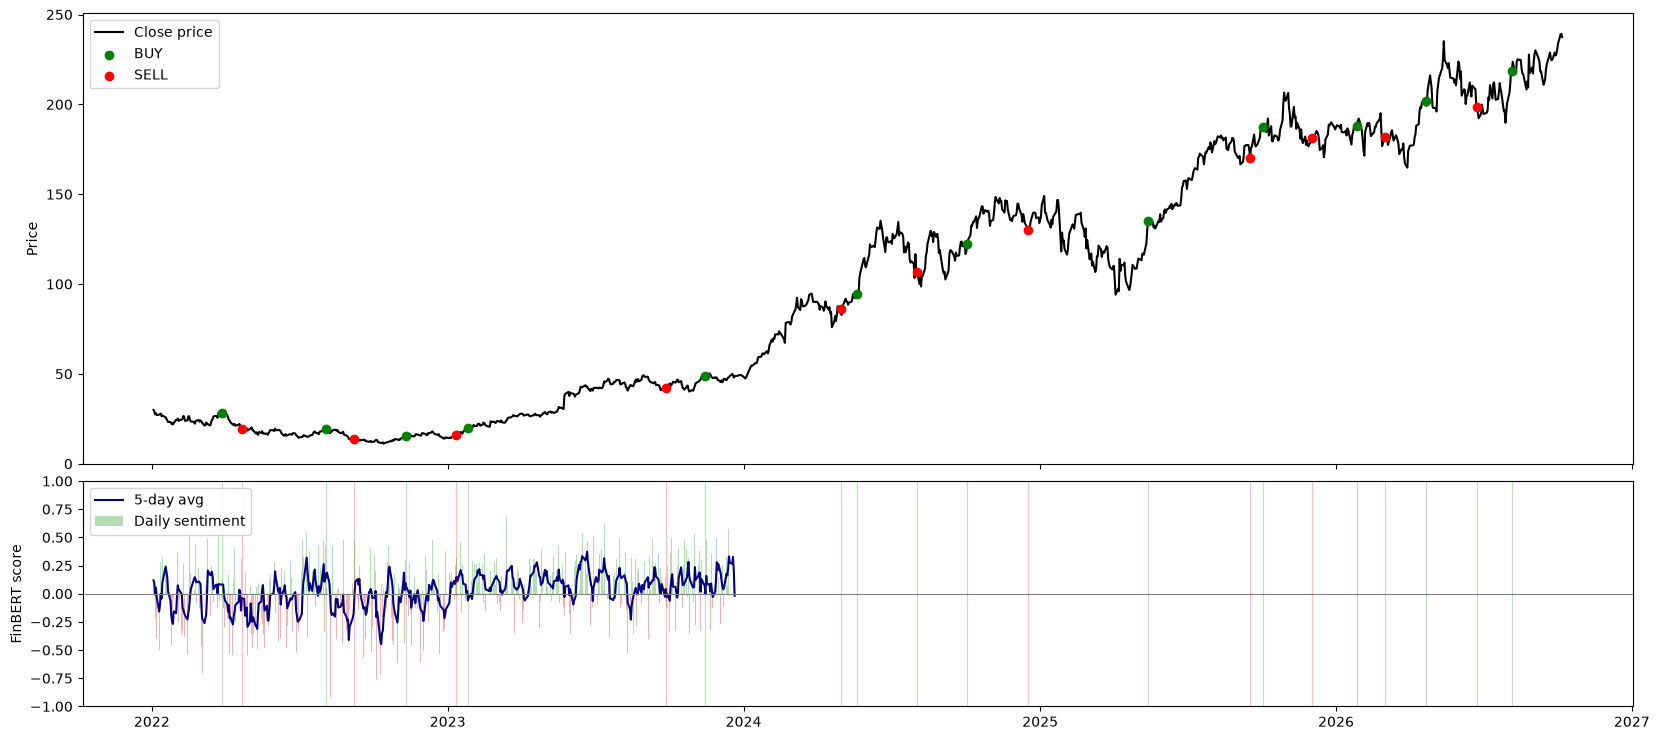

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1.5], "hspace": 0.05})

# Top chart
ax1.plot(close.index, close, label="Close price", color="black")
ax1.scatter(buys.index, buys["Close"], label="BUY", color="green", zorder=3)
ax1.scatter(sells.index, sells["Close"], label="SELL", color="red", zorder=3)
ax1.set_ylabel("Price")
ax1.legend(loc="upper left")

# Bottom: FinBERT sentiment (daily bars + smoothed line)
colors = np.where(sent >= 0, "tab:green", "tab:red")
ax2.bar(sent.index, sent, color=colors, alpha=0.35, width=1.0, label="Daily sentiment")
ax2.plot(sent_smooth.index, sent_smooth, color="navy", lw=1.5, label=f"{SMOOTH_DAYS}-day avg")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set_ylim(-1, 1)
ax2.set_ylabel("FinBERT score")
ax2.legend(loc="upper left")

# Faint vertical lines at each trade so you can see the sentiment at that moment
for d in buys.index:  ax2.axvline(d, color="green", alpha=0.25, lw=0.8)
for d in sells.index: ax2.axvline(d, color="red", alpha=0.25, lw=0.8)
plt.show()

In [15]:
# Sentiment on the day of each trade (smoothed, so days without news still get a value)
trade_col = prices["trade"].squeeze()
trade_mask = trade_col.isin([1, -1])
trades = pd.DataFrame({
    "type": np.where(trade_col[trade_mask] == 1, "BUY", "SELL"),
    "close": close[trade_mask],
    "sentiment_5d": sent_smooth[trade_mask],
})
trades["agrees"] = np.where(trades["type"] == "BUY", trades["sentiment_5d"] > 0, trades["sentiment_5d"] < 0)
display(trades)
print(f"Trades confirmed by sentiment: {trades['agrees'].mean():.0%}")

,type,close,sentiment_5d,agrees
Date,,,,
2022-03-28,BUY,28.103476,0.080152,True
2022-04-22,SELL,19.435110,-0.038217,True
2022-08-04,BUY,19.140385,0.139438,True
2022-09-07,SELL,13.664804,-0.173593,True
2022-11-10,BUY,15.693501,0.094587,True
2023-01-11,SELL,15.947680,0.113985,False
2023-01-26,BUY,19.736013,-0.060499,False
2023-09-27,SELL,42.341541,0.042645,False
2023-11-15,BUY,48.742432,-0.002770,False


Trades confirmed by sentiment: 22%
